# 03 — Preprocessing (Data Preparation)

**Fase 3 — CRISP-DM: Data Preparation** · Cubre las **Tareas 6, 7 y 8** del enunciado (Criterios C3 + C4, 50% de la nota).

Este notebook toma el dataset crudo y produce el dataset tratado que se guarda en `data/processed/`. **Cada decisión de tratamiento se justifica por escrito** — es lo que evalúa la rúbrica, más que el resultado concreto.

## Alcance

- ✅ Imputar, escalar, caracterizar valores atípicos, decidir sobre duplicados.
- ❌ **No se entrena ningún modelo ni se calcula ninguna métrica de clasificación** (§2.3 del PRD). Las implicaciones para el modelado se dejan como notas escritas.

## Decisiones heredadas de fases anteriores

| Origen | Decisión | Dónde se aplica |
|---|---|---|
| Loop C (`02_eda.ipynb`) | Las 3 filas con `DB > TB` se marcan como faltantes en **ambas** columnas, sin eliminar la fila | T6 |
| Loop C | Los resultados de T3 se reportan sobre datos **originales**, no imputados | T6 (nota) |
| Loop C | El conteo de outliers se repite **estratificado por edad**, como añadido al Tukey global | T8 |
| Fase 2c | `log1p` no es opcional para métodos basados en distancias — las variables tienen asimetría de hasta 10.5 | T7 |
| ADR 0004 | Los umbrales de referencia son los de Prati/ACG/AASLD, no derivados de este dataset | T8 |

## Decisiones acordadas para esta fase

| # | Decisión | Elegida |
|---|---|---|
| 1 | 13 duplicados exactos (F3-R13) | **Conservar**, con análisis de sensibilidad |
| 2 | Los 6 nulos que crea la marcación `DB > TB` | **Dejar como faltantes**, no imputar |
| 3 | Transformación logarítmica en T7 | **Tercera columna**, después del comparativo obligatorio |

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer

from src.config import (
    AGE_BANDS,
    BIOLOGICAL_LIMITS,
    BIOLOGICAL_LIMITS_SOURCED,
    CATEGORICAL_COLS,
    DATA_PROCESSED_DIR,
    GRID_COLOR,
    INK_PRIMARY,
    INK_SECONDARY,
    IQR_MULTIPLIER,
    NUMERIC_COLS,
    PROJECT_ROOT,
    SEX_COLORS,
    SKEWED_COLS,
    SURFACE,
    TARGET_COL,
)
from src.utils import (
    age_band_label,
    flag_biochemical_violations,
    load_raw_data,
    save_figure,
)

sns.set_theme(style="whitegrid")

df_raw = load_raw_data()
print(f"Dataset crudo: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
print(f"Nulos: {int(df_raw.isna().sum().sum())} (todos en 'A/G Ratio')")

Dataset crudo: 583 filas x 11 columnas
Nulos: 4 (todos en 'A/G Ratio')


## T2 (cont.) — Decisión sobre los 13 duplicados exactos

**Requisito F3-R13 [M].** La Tarea 2 pregunta por errores en el dataset; la Fase 2 detectó **13 filas duplicadas exactas** pero no decidió qué hacer con ellas, para no alterar los números que respondían a T1–T5. Esa decisión se toma aquí.

### El dilema

Una fila duplicada exacta significa que **las 11 columnas coinciden**: misma edad, mismo sexo, los 9 valores de laboratorio y el mismo diagnóstico. Hay dos explicaciones posibles y el dataset no permite distinguirlas:

| Explicación | Qué implica | Acción correspondiente |
|---|---|---|
| **Pacientes distintos** con analítica coincidente | Son datos legítimos | Conservar — eliminarlos borraría personas reales |
| **Error de captura** (misma persona registrada dos veces) | Los datos están inflados | Eliminar — dejarlos da doble peso a esas personas |

**Argumento a favor de "error de captura":** coincidir por azar en nueve variables, varias con decimales, es muy improbable.

**Argumento en contra:** varias de esas variables están **redondeadas en origen** (Loop C documentó que `TP` y `ALB` vienen a un decimal y `A/G Ratio` a dos). Con redondeo grueso, las coincidencias son bastante más probables de lo que sugiere la intuición.

Como ninguna evidencia es concluyente, **se mide el impacto de cada opción antes de decidir**.

In [2]:
dup_todas = df_raw.duplicated(keep=False)      # todas las copias implicadas
dup_extra = df_raw.duplicated(keep="first")    # solo las repeticiones (las que se irian)

print(f"Filas implicadas en alguna duplicacion: {int(dup_todas.sum())}")
print(f"Grupos duplicados distintos: {df_raw[dup_todas].groupby(list(df_raw.columns), dropna=False).ngroups}")
print(f"Filas que se eliminarian al deduplicar: {int(dup_extra.sum())}")

print("\n--- Composicion de las filas duplicadas ---")
print(df_raw[dup_todas].groupby(["Gender", "Selector"]).size().to_string())
pct_hombres_dup = 100 * (df_raw.loc[dup_todas, "Gender"] == "Male").mean()
pct_hombres_total = 100 * (df_raw["Gender"] == "Male").mean()
print(f"\nHombres entre los duplicados: {pct_hombres_dup:.1f}%  |  en la muestra completa: {pct_hombres_total:.1f}%")

print("\n--- Sensibilidad: estadisticos de T3 con y sin duplicados ---")
sin_dup = df_raw[~dup_extra]
filas = []
for col in ["TB", "DB"]:
    for etiqueta, d in (("con duplicados", df_raw), ("sin duplicados", sin_dup)):
        q1, q3 = d[col].quantile([0.25, 0.75])
        filas.append({"variable": col, "dataset": etiqueta, "n": len(d),
                      "media": round(d[col].mean(), 3), "mediana": round(d[col].median(), 3),
                      "std": round(d[col].std(), 3), "varianza": round(d[col].var(), 3),
                      "IQR": round(q3 - q1, 3)})
display(pd.DataFrame(filas).set_index(["variable", "dataset"]))

print("--- Cambio relativo al deduplicar ---")
for col in ["TB", "DB"]:
    a, b = df_raw[col].mean(), sin_dup[col].mean()
    print(f"  media de {col}: {a:.4f} -> {b:.4f}  ({100*(b-a)/a:+.2f}%)")
print(f"  tasa de diagnostico positivo: {100*(df_raw[TARGET_COL]==1).mean():.2f}% -> "
      f"{100*(sin_dup[TARGET_COL]==1).mean():.2f}%")
print(f"  proporcion de mujeres: {100*(df_raw['Gender']=='Female').mean():.2f}% -> "
      f"{100*(sin_dup['Gender']=='Female').mean():.2f}%")

Filas implicadas en alguna duplicacion: 26
Grupos duplicados distintos: 13
Filas que se eliminarian al deduplicar: 13

--- Composicion de las filas duplicadas ---
Gender  Selector
Female  1            2
        2            2
Male    1           18
        2            4

Hombres entre los duplicados: 84.6%  |  en la muestra completa: 75.6%

--- Sensibilidad: estadisticos de T3 con y sin duplicados ---


n  media  mediana    std  varianza  IQR
variable dataset                                                  
TB       con duplicados  583  3.299      1.0  6.210    38.558  1.8
         sin duplicados  570  3.322      1.0  6.268    39.287  1.8
DB       con duplicados  583  1.486      0.3  2.808     7.888  1.1
         sin duplicados  570  1.498      0.3  2.833     8.027  1.1

--- Cambio relativo al deduplicar ---
  media de TB: 3.2988 -> 3.3218  (+0.70%)
  media de DB: 1.4861 -> 1.4975  (+0.77%)
  tasa de diagnostico positivo: 71.36% -> 71.23%
  proporcion de mujeres: 24.36% -> 24.56%


**Interpretación y decisión — se conservan.**

### Lo que muestra la sensibilidad

Eliminar las 13 repeticiones **casi no mueve nada**:

| Métrica | Con duplicados (583) | Sin duplicados (570) | Cambio |
|---|---|---|---|
| Media de `TB` | 3.299 | 3.322 | **+0.70%** |
| Media de `DB` | 1.486 | 1.498 | **+0.77%** |
| Mediana de `TB` / `DB` | 1.0 / 0.3 | 1.0 / 0.3 | **sin cambio** |
| IQR de `TB` / `DB` | 1.8 / 1.1 | 1.8 / 1.1 | **sin cambio** |
| Tasa de diagnóstico positivo | 71.36% | 71.23% | −0.13 pp |
| Proporción de mujeres | 24.36% | 24.56% | +0.20 pp |

Ninguna conclusión de T1–T5 cambiaría de signo ni de magnitud. **La decisión es de bajo riesgo en cualquier dirección**, y eso mismo es lo que la resuelve.

### La decisión: conservar las 583 filas

Tres razones, en orden de peso:

1. **No hay evidencia de que sean errores.** Con `TP` y `ALB` redondeadas a un decimal, la coincidencia exacta es plausible por azar. Eliminar sobre una sospecha no verificada es destruir datos que pueden ser reales — y en la jerarquía del §9.4 del PRD, eliminar filas es el peor método disponible.
2. **El impacto medido es despreciable.** Si conservarlas distorsionara los resultados, el argumento se invertiría. No es el caso: el mayor cambio es 0.77% en una media que ya es un mal resumen de una distribución con asimetría 4.9.
3. **Es la opción reversible.** Conservarlas permite deduplicar más adelante; eliminarlas no permite recuperarlas.

### Qué se hace en su lugar

Se **documenta la duplicación como característica conocida del dataset** y se traspasa a la Fase 4 una advertencia concreta: al hacer el *split* train/test, las copias podrían caer en particiones distintas, **filtrando información del train al test** e inflando las métricas. La solución ahí es agrupar por fila idéntica antes de particionar, no eliminar ahora.

### Un detalle que conviene registrar

Los duplicados están **sobrerrepresentados en hombres**: 84.6% frente al 75.6% de la muestra completa. La diferencia es pequeña y sobre 26 filas no admite lectura estadística, pero se anota porque cualquier decisión sobre duplicados **afecta más a un sexo que al otro**, y este proyecto audita exactamente eso. Otra razón para no eliminarlas sin necesidad.

## T6 — Tratamiento de valores faltantes

> **Pregunta del enunciado:** *"Aplica técnicas de imputación de datos faltantes: media para variables numéricas y moda para no numéricas. Describe el proceso y discute ventajas y desventajas de cada técnica."*

### Punto de partida: dos tipos distintos de "faltante"

Antes de imputar hay que separar dos cosas que el pipeline trataría igual pero que **no son lo mismo**:

| Tipo | Cuántos | Qué significa | Origen |
|---|---|---|---|
| **Nunca medido** | 4 en `A/G Ratio` | El valor no existe en el registro | Dataset original (Q2) |
| **Medido, pero imposible** | 6 (3 en `TB` + 3 en `DB`) | El valor existe pero viola una restricción bioquímica | Los creamos nosotros al marcar `DB > TB` |

La distinción importa porque **determina si tiene sentido imputar**. Se desarrolla abajo.

In [3]:
violaciones = flag_biochemical_violations(df_raw)["db_gt_tb"]

df = df_raw.copy()
print("--- Filas que violan DB <= TB, ANTES de marcarlas ---")
display(df.loc[violaciones, ["Age", "Gender", "TB", "DB", "Selector"]])

# Decision de Loop C: se marcan AMBAS columnas, no se elimina la fila.
# No sabemos cual de los dos valores es el erroneo, asi que "corregir" seria inventar.
df.loc[violaciones, ["TB", "DB"]] = np.nan

print(f"\nNulos antes de marcar:  {int(df_raw.isna().sum().sum())}")
print(f"Nulos despues de marcar: {int(df.isna().sum().sum())}")
print("\n--- Inventario de faltantes ---")
inventario = pd.DataFrame({
    "n_faltantes": df.isna().sum()[df.isna().sum() > 0],
})
inventario["pct"] = (100 * inventario["n_faltantes"] / len(df)).round(2)
inventario["tipo"] = ["medido pero imposible", "medido pero imposible", "nunca medido"]
display(inventario)

print(f"Filas afectadas por la marcacion: {int(violaciones.sum())} "
      f"({100*violaciones.sum()/len(df):.1f}% de la muestra)")

--- Filas que violan DB <= TB, ANTES de marcarlas ---


,Age,Gender,TB,DB,Selector
246,55,Male,1.8,9.0,1
261,33,Male,1.5,7.0,1
279,48,Female,1.0,1.4,1



Nulos antes de marcar:  4
Nulos despues de marcar: 10

--- Inventario de faltantes ---


,n_faltantes,pct,tipo
TB,3,0.51,medido pero imposible
DB,3,0.51,medido pero imposible
A/G Ratio,4,0.69,nunca medido


Filas afectadas por la marcacion: 3 (0.5% de la muestra)


**Interpretación — por qué los 6 nuevos nulos NO se imputan.**

La marcación convierte 4 nulos en 10. Los 6 nuevos se dejan **como faltantes**, sin imputar, y esa es una decisión deliberada. Cuatro razones:

**1. Son de naturaleza distinta.** Los 4 de `A/G Ratio` nunca se midieron. Los 6 nuevos **sí se midieron — mal**. Rellenar con la media un valor que sabemos erróneo es apilar una invención encima de un error de laboratorio.

**2. Imputar es irreversible; dejar el hueco conserva la opción.** Si se rellenan ahora con la media, se **destruye el registro de que eran desconocidos**: la Fase 4 recibiría un número con apariencia de medido. Dejándolos vacíos, la Fase 4 puede imputar si le conviene. Se puede imputar después; no se puede des-imputar.

**3. Imputarlos ahora sería técnicamente incorrecto.** La advertencia de *data leakage* del PRD aplica: en el pipeline de modelado la imputación va **dentro de un `Pipeline` ajustado solo con el train set**. Una media calculada sobre el dataset completo contiene información de las filas que luego serán test → métricas infladas. Aplazar la decisión no es un descuido: **es lo correcto**.

**4. No bloquea nada aguas abajo.** En la Fase 4 hay tres caminos, todos viables: (a) modelos que aceptan `NaN` de forma nativa —`HistGradientBoostingClassifier`, LightGBM, XGBoost aprenden hacia qué rama enviar los faltantes—; (b) imputar dentro del `Pipeline`; (c) descartar esas 3 filas, que son el **0.5%** de la muestra.

### Sobre el requisito obligatorio

F3-R1 exige literalmente imputar *"los **4** faltantes de `A/G Ratio` por la MEDIA"*. Se refiere a esos 4 en concreto — los 6 nuevos **no existían** cuando se redactó la tarea, porque son consecuencia de un hallazgo posterior (Loop C). Tratarlos distinto no incumple el requisito, y de hecho aporta un caso real a la discusión de ventajas y desventajas que la propia T6 exige.

### T6.1 — Imputación exigida por el enunciado: media y moda

**Requisitos F3-R1 y F3-R2 [M].** Se implementan con `SimpleImputer` de scikit-learn, que es la herramienta estándar y la que después se integrará en el `Pipeline` de modelado.

- **`strategy="mean"`** sobre `A/G Ratio` — única columna numérica con faltantes de tipo "nunca medido".
- **`strategy="most_frequent"`** sobre `Gender` — única variable no numérica.

> **Ambigüedad A3 del PRD:** `Gender` **no tiene faltantes**, así que la imputación por moda es un ***no-op***: no altera ninguna fila. Se implementa igualmente porque el criterio C3 la exige de forma literal, y porque deja el pipeline preparado para datos nuevos que sí puedan traer huecos. Se documenta explícitamente en vez de disimularlo.

In [4]:
# --- F3-R1: imputacion por MEDIA de la variable numerica con faltantes ---
imputador_media = SimpleImputer(strategy="mean")
faltan_ag = df["A/G Ratio"].isna()

df_imputado = df.copy()
df_imputado["A/G Ratio"] = imputador_media.fit_transform(df[["A/G Ratio"]]).ravel()

media_usada = imputador_media.statistics_[0]
print("=== F3-R1: imputacion por MEDIA (A/G Ratio) ===")
print(f"Filas imputadas: {int(faltan_ag.sum())}  (indices {list(df.index[faltan_ag])})")
print(f"Media calculada sobre las {int(df['A/G Ratio'].notna().sum())} filas con dato: {media_usada:.6f}")
print(f"Valor asignado a las 4 filas: {media_usada:.2f}")

print("\n--- Efecto sobre la dispersion (variance shrinkage) ---")
antes, despues = df["A/G Ratio"], df_imputado["A/G Ratio"]
resumen = pd.DataFrame({
    "n": [int(antes.notna().sum()), len(despues)],
    "media": [round(antes.mean(), 4), round(despues.mean(), 4)],
    "std": [round(antes.std(), 4), round(despues.std(), 4)],
    "varianza": [round(antes.var(), 6), round(despues.var(), 6)],
}, index=["antes de imputar", "despues de imputar"])
display(resumen)
print(f"Reduccion de la varianza: {100*(despues.var()-antes.var())/antes.var():+.3f}%")

# --- F3-R2: imputacion por MODA de la variable categorica ---
print("\n=== F3-R2: imputacion por MODA (Gender) ===")
imputador_moda = SimpleImputer(strategy="most_frequent")
gender_original = df[CATEGORICAL_COLS[0]].copy()
df_imputado[CATEGORICAL_COLS[0]] = imputador_moda.fit_transform(df[CATEGORICAL_COLS]).ravel()

print(f"Faltantes en '{CATEGORICAL_COLS[0]}': {int(gender_original.isna().sum())}")
print(f"Moda detectada por SimpleImputer: {imputador_moda.statistics_[0]}")
n_alteradas = int((df_imputado[CATEGORICAL_COLS[0]] != gender_original).sum())
print(f"Filas alteradas por la imputacion: {n_alteradas}  -> es un NO-OP (ambiguedad A3)")

print(f"\nNulos restantes tras T6.1: {int(df_imputado.isna().sum().sum())} "
      f"(los 6 de TB/DB, dejados a proposito)")

=== F3-R1: imputacion por MEDIA (A/G Ratio) ===
Filas imputadas: 4  (indices [209, 241, 253, 312])
Media calculada sobre las 579 filas con dato: 0.947064
Valor asignado a las 4 filas: 0.95

--- Efecto sobre la dispersion (variance shrinkage) ---


,n,media,std,varianza
antes de imputar,579,0.9471,0.3196,0.102139
despues de imputar,583,0.9471,0.3185,0.101437


Reduccion de la varianza: -0.687%

=== F3-R2: imputacion por MODA (Gender) ===
Faltantes en 'Gender': 0
Moda detectada por SimpleImputer: Male
Filas alteradas por la imputacion: 0  -> es un NO-OP (ambiguedad A3)

Nulos restantes tras T6.1: 6 (los 6 de TB/DB, dejados a proposito)


**Interpretación — la imputación funcionó, y su principal defecto ya es visible.**

### Lo que se ejecutó

| Requisito | Variable | Estrategia | Filas afectadas | Valor asignado |
|---|---|---|---|---|
| F3-R1 [M] | `A/G Ratio` | Media | **4** | **0.95** |
| F3-R2 [M] | `Gender` | Moda | **0** (*no-op*) | — (moda = `Male`) |

La media se calculó sobre las 579 filas con dato: **0.947064**, que redondeada al mismo formato del dataset es **0.95**.

### El efecto que el PRD anticipaba: *variance shrinkage*

Rellenar cuatro huecos con el valor promedio **reduce artificialmente la dispersión**, porque añade cuatro observaciones que están exactamente en el centro:

| | n | Media | Std | Varianza |
|---|---|---|---|---|
| Antes de imputar | 579 | 0.9471 | 0.3196 | 0.102139 |
| Después de imputar | 583 | 0.9471 | 0.3185 | 0.101437 |

**La varianza baja un 0.687%.** Es una reducción pequeña —solo son 4 filas de 583— pero **es real y va siempre en la misma dirección**: la imputación por media nunca aumenta la varianza. Con un 10% de faltantes en vez de un 0.7%, el efecto sería severo.

Nótese que **la media no cambia en absoluto** (0.9471 antes y después). Eso es propio del método: imputar con la media preserva el centro y comprime la dispersión. Por eso el PRD ordena reportar los estadísticos de **T3 sobre los datos originales** — calcularlos después de imputar distorsionaría justamente lo que T3 pide medir.

### El *no-op* de la moda

`Gender` no tiene faltantes, así que `SimpleImputer` no alteró ninguna fila. Se implementa igual por dos razones: el criterio C3 lo exige literalmente, y deja el pipeline preparado para datos futuros. **Declararlo es más honesto que presentar un paso que no hizo nada como si hubiera hecho algo.**

### T6.2 — [V] Imputación determinista: ¿era la media la mejor opción?

**Requisito F3-R5 [V].** `A/G Ratio` **no es una medición independiente**: es una variable derivada por aritmética de otras dos que sí están medidas.

```
A/G Ratio = Albúmina / Globulina = ALB / (TP − ALB)
```

Traducción a lenguaje llano: la sangre lleva proteínas de dos tipos, albúmina y globulina. `TP` (proteína total) es la suma de ambas, y `ALB` es la parte de albúmina. Restando, `TP − ALB` da la globulina. El cociente entre ambas es `A/G Ratio`.

**Si las otras dos variables están medidas en esas 4 filas, el valor no hay que estimarlo: se puede calcular.**

> ⚠️ **Esto es adicional al requisito obligatorio, nunca su reemplazo** (§0.4 del PRD). La imputación por media ya se ejecutó arriba y es la que responde a la rúbrica.

In [5]:
print("=== Comparacion: imputacion determinista vs. por media ===")
print("Formula: A/G Ratio = ALB / (TP - ALB)\n")

print(f"Riesgo de division por cero -> filas con TP == ALB: {int((df['TP'] == df['ALB']).sum())}")

comparacion = df.loc[faltan_ag, ["Age", "Gender", "TP", "ALB", TARGET_COL]].copy()
comparacion["globulina"] = (comparacion["TP"] - comparacion["ALB"]).round(2)
comparacion["A/G_determinista"] = (comparacion["ALB"] / comparacion["globulina"]).round(2)
comparacion["A/G_por_media"] = round(media_usada, 2)
comparacion["diferencia"] = (comparacion["A/G_determinista"] - comparacion["A/G_por_media"]).round(2)
comparacion["error_relativo_%"] = (
    100 * comparacion["diferencia"].abs() / comparacion["A/G_determinista"]
).round(1)
display(comparacion)

print("--- Que tan exacta es la formula sobre las filas que SI tienen el dato? ---")
verificacion = df.dropna(subset=["A/G Ratio", "TP", "ALB"]).copy()
verificacion["calculado"] = verificacion["ALB"] / (verificacion["TP"] - verificacion["ALB"])
verificacion["error_abs"] = (verificacion["calculado"] - verificacion["A/G Ratio"]).abs()
print(f"  filas comparables: {len(verificacion)}")
print(f"  error absoluto medio: {verificacion['error_abs'].mean():.4f}")
print(f"  mediana: {verificacion['error_abs'].median():.4f}  |  maximo: {verificacion['error_abs'].max():.4f}")
print(f"  filas con error > 0.05: {int((verificacion['error_abs']>0.05).sum())} "
      f"({100*(verificacion['error_abs']>0.05).mean():.1f}%)")

=== Comparacion: imputacion determinista vs. por media ===
Formula: A/G Ratio = ALB / (TP - ALB)

Riesgo de division por cero -> filas con TP == ALB: 0


,Age,Gender,TP,ALB,Selector,globulina,A/G_determinista,A/G_por_media,diferencia,error_relativo_%
209,45,Female,6.6,3.9,1,2.7,1.44,0.95,0.49,34.0
241,51,Male,6.5,3.1,1,3.4,0.91,0.95,-0.04,4.4
253,35,Female,5.2,2.7,2,2.5,1.08,0.95,0.13,12.0
312,27,Male,8.5,4.8,2,3.7,1.30,0.95,0.35,26.9


--- Que tan exacta es la formula sobre las filas que SI tienen el dato? ---
  filas comparables: 579
  error absoluto medio: 0.0514
  mediana: 0.0310  |  maximo: 2.3000
  filas con error > 0.05: 191 (33.0%)


**Interpretación — la media falla en 3 de las 4 filas, y por mucho.**

### La comparación, paciente por paciente

| Fila | Sexo | `TP` | `ALB` | Globulina | **Determinista** | **Por media** | Error relativo |
|---|---|---|---|---|---|---|---|
| 209 | Female | 6.6 | 3.9 | 2.7 | **1.44** | 0.95 | **34.0%** |
| 241 | Male | 6.5 | 3.1 | 3.4 | **0.91** | 0.95 | 4.4% |
| 253 | Female | 5.2 | 2.7 | 2.5 | **1.08** | 0.95 | 12.0% |
| 312 | Male | 8.5 | 4.8 | 3.7 | **1.30** | 0.95 | 26.9% |

**No hay riesgo de división por cero:** 0 filas con `TP == ALB`.

En **3 de las 4 filas** la media se aleja sustancialmente del valor que la fórmula calcula. El caso 209 es el más claro: el valor real es **1.44** y la media asigna **0.95** — un error del **34%**, y en la dirección de hacer parecer peor la función hepática de esa paciente de lo que realmente es.

Solo la fila 241 (0.91 vs 0.95) queda cerca, y es coincidencia: ese paciente está próximo al promedio de la cohorte.

### Por qué pasa esto

La imputación por media asigna **el mismo número a todos**, ignorando por completo la información disponible de cada paciente. Aquí esa información existe y es suficiente para calcular el valor exacto — pero la media no la mira.

### Honestidad sobre "exacta"

La fórmula **no reproduce el dato perfectamente** en las filas donde sí existe. Sobre 579 filas comparables:

- Error absoluto medio: **0.0514**
- Mediana: **0.0310** · Máximo: **2.30**
- **191 filas (33.0%)** con error superior a 0.05

La causa —documentada en Loop C— es el **redondeo en origen**: `TP` y `ALB` vienen a un decimal y `A/G Ratio` a dos. Dividir dos cantidades ya redondeadas amplifica el error relativo, sobre todo cuando la globulina es pequeña.

Así que la imputación determinista es **conceptualmente superior pero no exacta en la práctica sobre este dataset concreto**. Se reporta así en vez de venderla como perfecta.

### Jerarquía de calidad de imputación

| Método | Precisión | Cuándo aplica | En este caso |
|---|---|---|---|
| **Determinista (fórmula)** | Alta (limitada aquí por el redondeo) | Existe una relación algebraica conocida | ✅ Aplicable a `A/G Ratio` |
| KNN / MICE | Buena | Hay estructura multivariante aprovechable | Posible, no necesario aquí |
| **Media / mediana** | Pobre | Último recurso | ⚠️ **Lo que exige el enunciado** |
| Eliminar filas (*listwise*) | Peor | Casi nunca | ❌ Descartado |

### Conclusión

**El propio paper que publicó este dataset usó imputación por media.** Es una limitación metodológica identificable: existiendo una relación algebraica exacta entre las variables, recurrir al promedio descarta información disponible. Que el enunciado pida la media no lo hace la mejor opción — lo hace el ejercicio pedido, y **saber distinguir ambas cosas es parte de lo que se evalúa**.

### T6.3 — [M] Ventajas y desventajas de las técnicas de imputación

**Requisito F3-R3 [M].** El enunciado pide discutir explícitamente las técnicas, no solo aplicarlas.

| Técnica | Cómo funciona | Ventajas | Desventajas | Cuándo usarla |
|---|---|---|---|---|
| **Media** | Rellena con el promedio de la columna | Trivial de implementar y explicar · No cambia la media de la variable · Rápida · Estándar en `scikit-learn` | **Reduce la varianza** (visto arriba: −0.687%) · **Distorsiona las correlaciones** · Ignora toda la información del resto de la fila · Sensible a valores extremos · Absurda si la distribución es asimétrica | Faltantes escasos y aleatorios, en variables aproximadamente simétricas |
| **Mediana** | Rellena con el valor central | Todo lo de la media, pero **robusta a extremos** | Mismos problemas de varianza y correlaciones | Preferible a la media cuando hay asimetría — que es el caso de 5 de las 9 variables de este dataset |
| **Moda** | Rellena con la categoría más frecuente | Única opción simple para variables categóricas | **Refuerza el desbalance** de la clase mayoritaria · Sin sentido si las categorías están parejas | Variables categóricas con faltantes escasos |
| **Determinista (fórmula)** | Calcula el valor desde una relación conocida | **Usa la información real de cada fila** · No distorsiona la distribución · Reproducible | Requiere que exista la relación · Puede propagar el error de sus insumos (redondeo, aquí) · Riesgo de división por cero | Cuando la variable es derivada de otras — el caso de `A/G Ratio` |
| **KNN / MICE** | Estima desde los pacientes más parecidos | Aprovecha la estructura multivariante · Mucho mejor que la media | Costosa · Difícil de explicar · **Puede filtrar información del test si se ajusta mal** | Faltantes abundantes y con estructura |
| **Eliminar filas** | Descarta las filas incompletas | No inventa ningún valor | **Pierde datos** · **Sesga la muestra** si los faltantes no son aleatorios · Reduce la potencia estadística | Casi nunca; solo con faltantes mínimos y demostrablemente aleatorios |

### La desventaja que más importa en este proyecto

Todas las técnicas basadas en un estadístico de la columna —media, mediana, moda— comparten un mismo defecto de fondo: **tratan a todos los pacientes como intercambiables**. Asignan el mismo valor a una mujer de 30 años y a un hombre de 70, ignorando que este proyecto ya demostró que los rangos de referencia **difieren por sexo y por edad** (ADR 0004, Loop C).

Con 4 faltantes de 583 el efecto es despreciable. Pero el razonamiento escala: en un dataset con muchos huecos, imputar por media **homogeneizaría artificialmente subgrupos que el análisis de equidad necesita distinguir** — y lo haría más agresivamente sobre el grupo minoritario, que aporta menos observaciones al promedio.

Queda registrado como advertencia para la Fase 4+.

### T6.4 — [M] Ventajas y desventajas de las técnicas de normalización

> **Ambigüedad A2 del PRD.** El enunciado, dentro de la Tarea 6 (imputación), pide *"ventajas y desventajas de cada técnica **de normalización**"* — texto copiado de la Tarea 7. Es una **errata del enunciado**. Se resuelve cubriendo **ambas** discusiones: la de imputación (arriba) y la de normalización (aquí), que cuesta un apartado y blinda el Criterio 3.

**Qué es normalizar y por qué se hace.** Las nueve variables numéricas están en escalas totalmente distintas: `Alkphos` llega a 2110, mientras `ALB` se mueve entre 0.9 y 5.5. Sin ajustar la escala, cualquier método que mida distancias o use gradientes tratará a `Alkphos` como si fuera **cientos de veces más importante** que `ALB` — y esa diferencia es un **artefacto de las unidades de medida**, no de la relevancia clínica.

| Técnica | Fórmula | Rango resultante | Ventajas | Desventajas |
|---|---|---|---|---|
| **MinMax** | `(x − min) / (max − min)` | Acotado [0, 1] | Rango predecible · Preserva la forma de la distribución · Requisito de algunas redes neuronales | **Muy sensible a valores extremos**: un solo caso alto infla el denominador y comprime a todos los demás contra el cero · Un valor nuevo fuera del rango original se sale de [0,1] |
| **Z-Score** | `(x − μ) / σ` | Ilimitado | **Más robusto a extremos** · Comparable entre variables · Base de muchos métodos estadísticos | La media y la desviación **también se ven afectadas** por los extremos · El resultado no está acotado · Interpretación menos intuitiva |
| **RobustScaler** | `(x − mediana) / IQR` | Ilimitado | **El más robusto**: usa mediana e IQR, insensibles a la cola | No lo pide el enunciado · Menos habitual |
| **`log1p` + escalado** | `log(1 + x)`, después escalar | Según el escalador | **Ataca la causa**: comprime la cola en lugar de convivir con ella | Cambia la interpretación de la variable · Solo para valores positivos |

**Diferencia conceptual entre las dos primeras:** MinMax responde *"¿dónde está este paciente entre el mínimo y el máximo observados?"*; Z-Score responde *"¿a cuántas desviaciones del promedio está?"*. La primera depende por completo de **dos** pacientes —el más bajo y el más alto—; la segunda, de **toda** la distribución. Con las colas que tiene este dataset, esa diferencia es decisiva.

**La conclusión se demuestra con números en la Tarea 7**, donde se aplican ambas y se mide el efecto sobre las medianas.

---

## T7 — Normalización y escalado

> **Pregunta del enunciado:** *"Aplica normalización MinMax y estandarización Z-Score a las variables numéricas. Describe el proceso, compara ventajas y desventajas, y concluye cuál conviene."*

### Por qué hay que escalar

Las nueve variables numéricas viven en escalas incomparables: `Alkphos` llega a **2110** y `ALB` se mueve entre **0.9 y 5.5**. Un método que mida distancias entre pacientes —o que use gradientes— trataría a `Alkphos` como si fuera cientos de veces más importante que `ALB`, cuando esa diferencia es un **artefacto de las unidades**, no de la relevancia clínica.

Escalar pone a todas las variables en un terreno comparable.

### Las tres variantes que se aplican

| # | Variante | Qué hace | Estatus |
|---|---|---|---|
| 1 | **MinMax** | Comprime al rango [0, 1] usando el mínimo y el máximo | **[M]** F3-R6 |
| 2 | **Z-Score** | Centra en 0 y divide por la desviación estándar | **[M]** F3-R7 |
| 3 | **`log1p` + Z-Score** | Comprime la cola derecha *antes* de estandarizar | **[V]** — añadido, ver abajo |

**Sobre la tercera variante.** La Fase 2c (`02c_eda_clustering.ipynb`) demostró empíricamente que en estas variables —con asimetría de hasta 10.5— cualquier método basado en distancias queda dominado por unos pocos pacientes extremos. Se añade como **valor agregado, después del comparativo obligatorio**, nunca en su reemplazo (§0.4 del PRD).

> **Nota técnica:** los escaladores de `scikit-learn` **toleran valores faltantes**: los ignoran al calcular sus estadísticos y los preservan en la salida. Los 6 `NaN` de `TB`/`DB` que dejamos a propósito en T6 no rompen nada y siguen siendo `NaN` después de escalar.

In [6]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

X = df_imputado[NUMERIC_COLS]
print(f"Valores faltantes que entran al escalado: {int(X.isna().sum().sum())} (TB y DB)")

# --- F3-R6 [M]: MinMax ---
escalador_minmax = MinMaxScaler()
X_minmax = pd.DataFrame(escalador_minmax.fit_transform(X), columns=NUMERIC_COLS, index=X.index)

# --- F3-R7 [M]: Z-Score ---
escalador_zscore = StandardScaler()
X_zscore = pd.DataFrame(escalador_zscore.fit_transform(X), columns=NUMERIC_COLS, index=X.index)

# --- [V]: log1p sobre las variables sesgadas, despues Z-Score ---
X_log = X.copy()
X_log[SKEWED_COLS] = np.log1p(X_log[SKEWED_COLS])
X_logz = pd.DataFrame(StandardScaler().fit_transform(X_log), columns=NUMERIC_COLS, index=X.index)

print(f"NaN preservados tras escalar -> MinMax: {int(X_minmax.isna().sum().sum())}, "
      f"Z-Score: {int(X_zscore.isna().sum().sum())}")

# --- F3-R9 [V]: donde queda la MEDIANA de cada variable ---
print("\n=== F3-R9: posicion de la mediana bajo cada escalado ===")
evidencia = pd.DataFrame({
    "skew": X.skew().round(2),
    "min": X.min(),
    "max": X.max(),
    "mediana_original": X.median().round(2),
    "mediana_MinMax": X_minmax.median().round(4),
    "mediana_ZScore": X_zscore.median().round(4),
    "mediana_logZ": X_logz.median().round(4),
})
evidencia["pct_del_rango"] = (100 * evidencia["mediana_MinMax"]).round(1)
display(evidencia)

print("--- Cuantos pacientes quedan aplastados bajo 0.1 con MinMax ---")
for c in NUMERIC_COLS:
    pct = 100 * (X_minmax[c] < 0.1).mean()
    marca = "  <-- aplastada" if pct > 50 else ""
    print(f"  {c:>10}: {pct:5.1f}%{marca}")

print("\n--- Por que pasa: cuanto estira un solo paciente el rango ---")
for c in SKEWED_COLS:
    q1, q3 = X[c].quantile([0.25, 0.75])
    rango = X[c].max() - X[c].min()
    print(f"  {c:>10}: rango={rango:8.1f}  IQR={q3-q1:7.1f}  -> el rango es {rango/(q3-q1):5.1f}x el IQR")

Valores faltantes que entran al escalado: 6 (TB y DB)
NaN preservados tras escalar -> MinMax: 6, Z-Score: 6

=== F3-R9: posicion de la mediana bajo cada escalado ===


,skew,min,max,mediana_original,mediana_MinMax,mediana_ZScore,mediana_logZ,pct_del_rango
Age,-0.03,4.0,90.0,45.00,0.4767,0.0157,0.0157,47.7
TB,4.89,0.4,75.0,1.00,0.0080,-0.3712,-0.4883,0.8
DB,3.27,0.1,19.7,0.30,0.0102,-0.4177,-0.5217,1.0
Alkphos,3.77,63.0,2110.0,208.00,0.0708,-0.3402,-0.2960,7.1
Sgpt,6.55,10.0,2000.0,35.00,0.0126,-0.2505,-0.2253,1.3
Sgot,10.55,10.0,4929.0,42.00,0.0065,-0.2353,-0.2267,0.6
TP,-0.29,2.7,9.6,6.60,0.5652,0.1077,0.1077,56.5
ALB,-0.04,0.9,5.5,3.10,0.4783,-0.0527,-0.0527,47.8
A/G Ratio,1.00,0.3,2.8,0.95,0.2588,-0.0000,-0.0000,25.9


--- Cuantos pacientes quedan aplastados bajo 0.1 con MinMax ---
         Age:   1.7%
          TB:  89.4%  <-- aplastada
          DB:  82.3%  <-- aplastada
     Alkphos:  66.6%  <-- aplastada
        Sgpt:  94.2%  <-- aplastada
        Sgot:  95.9%  <-- aplastada
          TP:   0.5%
         ALB:   0.5%
   A/G Ratio:   9.9%

--- Por que pasa: cuanto estira un solo paciente el rango ---
          TB: rango=    74.6  IQR=    1.8  -> el rango es  41.4x el IQR
          DB: rango=    19.6  IQR=    1.0  -> el rango es  19.1x el IQR
     Alkphos: rango=  2047.0  IQR=  122.5  -> el rango es  16.7x el IQR
        Sgpt: rango=  1990.0  IQR=   37.5  -> el rango es  53.1x el IQR
        Sgot: rango=  4919.0  IQR=   62.0  -> el rango es  79.3x el IQR


**Interpretación — F3-R8 y F3-R9: la conclusión es Z-Score, y la evidencia es contundente.**

### Dónde queda la mediana con cada método

El escalado no debería cambiar *dónde vive la mayoría de los pacientes* respecto del resto. Esta tabla mide si lo hace:

| Variable | *Skew* | Mediana MinMax | % del rango | Mediana Z-Score |
|---|---|---|---|---|
| `Sgot` | 10.55 | **0.0065** | **0.65%** | −0.2353 |
| `TB` | 4.89 | **0.0080** | **0.80%** | −0.3712 |
| `DB` | 3.27 | **0.0102** | **1.02%** | −0.4177 |
| `Sgpt` | 6.55 | **0.0126** | **1.26%** | −0.2505 |
| `Alkphos` | 3.77 | 0.0708 | 7.08% | −0.3402 |
| `A/G Ratio` | 1.00 | 0.2588 | 25.88% | −0.0000 |
| `Age` | −0.03 | 0.4767 | 47.67% | 0.0157 |
| `ALB` | −0.04 | 0.4783 | 47.83% | −0.0527 |
| `TP` | −0.29 | 0.5652 | 56.52% | 0.1077 |

**Lee la columna "% del rango".** Con MinMax, el paciente **mediano** de `Sgot` —el que deja a la mitad de la cohorte por debajo y a la mitad por encima— queda en el **0.65% del rango**. Prácticamente pegado al cero.

Y no es un caso aislado:

| Variable | Pacientes bajo 0.1 tras MinMax |
|---|---|
| `Sgot` | **95.9%** |
| `Sgpt` | **94.2%** |
| `TB` | **89.4%** |
| `DB` | **82.3%** |
| `Alkphos` | **66.6%** |

En `Sgot`, **96 de cada 100 pacientes acaban comprimidos en el primer 10% de la escala**. Toda la variabilidad clínicamente relevante —la diferencia entre alguien con 30 y alguien con 150— se aplasta hasta volverse indistinguible.

### Por qué ocurre

MinMax divide por `max − min`. Ese denominador lo fijan **exactamente dos pacientes**: el más bajo y el más alto. En variables con cola larga, el máximo está lejísimos del grueso de los datos:

| Variable | Rango | IQR | El rango es… |
|---|---|---|---|
| `Sgot` | 4919 | 62.0 | **79.3× el IQR** |
| `Sgpt` | 1990 | 37.5 | **53.1× el IQR** |
| `TB` | 74.6 | 1.8 | **41.4× el IQR** |

El IQR describe dónde vive el 50% central de los pacientes. Que el rango total sea **79 veces** ese ancho significa que un solo paciente extremo —el de `Sgot` = 4929— define casi toda la escala, y todos los demás se reparten la fracción que queda.

### El contraste que lo confirma

Fíjate en las tres últimas filas de la tabla: `Age`, `ALB` y `TP` tienen asimetría cercana a cero, y sus medianas con MinMax quedan en **47.7%, 47.8% y 56.5%** — justo donde deberían, cerca del centro.

**El problema no es MinMax en abstracto: es MinMax aplicado a variables con cola larga.** En variables simétricas se comporta perfectamente.

### Conclusión (F3-R8)

**Para este dataset, Z-Score es la opción más adecuada de las dos exigidas.**

| Criterio | MinMax | Z-Score |
|---|---|---|
| Rango resultante | Acotado [0, 1] | Ilimitado |
| Sensibilidad a extremos | **Muy alta** — la definen 2 pacientes | Moderada — la definen media y desviación de los 583 |
| Preserva la variabilidad del grueso | ❌ **No**: 96% de `Sgot` bajo 0.1 | ✅ Sí |
| Valores nuevos fuera del rango original | Se salen de [0, 1] | Sin problema |
| En este dataset | ❌ Destruye la señal en 5 de 9 variables | ✅ Aceptable |

Z-Score también se ve afectado por los extremos —media y desviación no son robustas—, pero **el efecto se reparte entre las 583 observaciones** en vez de recaer en dos. Esa es toda la diferencia.

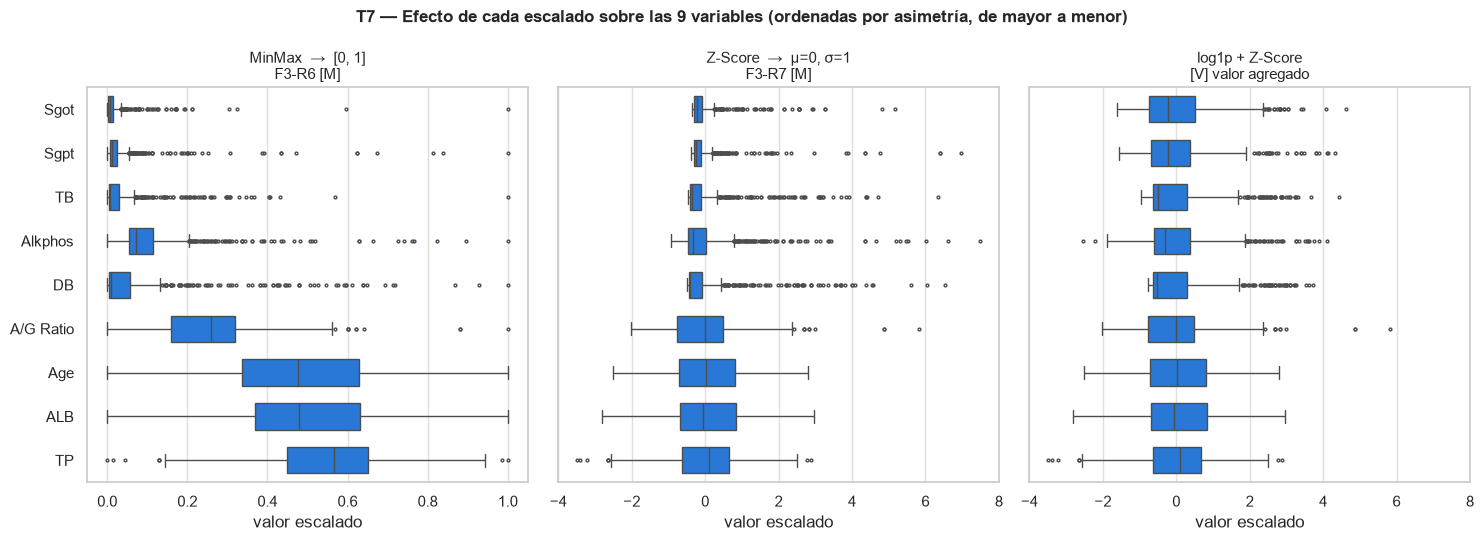

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharey=True)

variantes = [
    (X_minmax, "MinMax  →  [0, 1]", "F3-R6 [M]"),
    (X_zscore, "Z-Score  →  μ=0, σ=1", "F3-R7 [M]"),
    (X_logz, "log1p + Z-Score", "[V] valor agregado"),
]
orden = X.skew().sort_values(ascending=False).index.tolist()

for ax, (datos, titulo, etiqueta) in zip(axes, variantes):
    largo = datos[orden].melt(var_name="variable", value_name="valor")
    sns.boxplot(data=largo, y="variable", x="valor", ax=ax, order=orden,
                color="#2a78d6", fliersize=2, linewidth=1, width=0.6, saturation=1)
    ax.set_title(f"{titulo}\n{etiqueta}", fontsize=10.5)
    ax.set_xlabel("valor escalado")
    ax.set_ylabel("")
    ax.grid(axis="x", color=GRID_COLOR)
    ax.grid(axis="y", visible=False)

axes[0].set_xlim(-0.05, 1.05)
for ax in axes[1:]:
    ax.set_xlim(-4, 8)

fig.suptitle("T7 — Efecto de cada escalado sobre las 9 variables (ordenadas por asimetría, "
             "de mayor a menor)", fontsize=12, fontweight="bold")
fig.tight_layout()
save_figure(fig, "fase3_t7_escalado.png")
plt.show()

**Interpretación de la figura — y qué aporta la tercera variante.**

**Panel izquierdo (MinMax).** Las cinco variables de arriba —las más asimétricas— aparecen como **una línea pegada al cero con puntos sueltos a la derecha**. La caja, que debería mostrar dónde está el 50% central de los pacientes, se ha reducido a un trazo. Las tres de abajo (`TP`, `ALB`, `Age`), simétricas, muestran cajas normales y centradas.

**Panel central (Z-Score).** Las cajas de las variables sesgadas siguen siendo **estrechas comparadas con las simétricas** — Z-Score no corrige la asimetría, solo cambia las unidades. Pero ya son cajas visibles y no un trazo pegado al borde, y la escala la fija ahora toda la distribución en vez de dos pacientes.

**Panel derecho (`log1p` + Z-Score).** Es el más equilibrado de los tres: las cajas tienen tamaños comparables entre variables y la cola derecha, aunque presente, deja de dominar la escala.

### Qué aporta la tercera variante y por qué NO reemplaza a las otras

`log1p` **ataca la causa en vez de convivir con ella**. MinMax y Z-Score aceptan la asimetría como viene y solo cambian de unidades; el logaritmo comprime la cola, así que la variable que llega al escalador ya no está dominada por unos pocos casos.

**Pero cambia lo que la variable significa.** Después de `log1p`, una diferencia de una unidad ya no representa una diferencia fija de U/L, sino un **factor multiplicativo**. Para un biomarcador esto suele ser incluso más razonable clínicamente —pasar de 30 a 60 es un cambio más comparable a pasar de 300 a 600 que a pasar de 300 a 330— pero es una decisión que hay que declarar, no un ajuste cosmético.

### ⚠️ Advertencia obligatoria de *data leakage*

En este notebook el escalado se aplica **sobre el dataset completo**, y eso es **aceptable aquí porque no se entrena ningún modelo**: el objetivo es comparar métodos, no producir predicciones.

En el pipeline de modelado (Fase 4+) esto **debe cambiar**: el escalador tiene que ir **dentro de un `Pipeline` ajustado únicamente con el train set**. Un `StandardScaler` ajustado sobre todo el dataset calcula su media y desviación usando también las filas que después serán test — eso filtra información del test al entrenamiento e **infla optimistamente las métricas**.

La misma advertencia aplica al `SimpleImputer` de T6 y a cualquier transformación que aprenda parámetros de los datos.

---

## T8 — Identificación de valores atípicos

> **Pregunta del enunciado:** *"Detecta valores atípicos en `Sgot`, `TP`, `ALB` y `A/G Ratio` mediante boxplots. Cuantifica cuántos hay y describe los patrones observados."*

### El método: regla de Tukey

Un *boxplot* dibuja la caja entre el primer cuartil (`Q1`, el valor que deja por debajo al 25% de los pacientes) y el tercero (`Q3`, que deja por debajo al 75%). La distancia entre ambos es el **IQR**, y describe dónde vive el 50% central.

La regla de Tukey marca como atípico todo lo que caiga fuera de:

```
[ Q1 − 1.5 × IQR ,  Q3 + 1.5 × IQR ]
```

El multiplicador **1.5** vive en `src/config.py` como `IQR_MULTIPLIER`, no escrito a mano.

### ⚠️ Lo que este apartado NO hace

**No se elimina ningún valor atípico.** En datos clínicos, un `Sgot` de 4929 con mediana 42 **no es ruido: es el paciente más grave de la cohorte** — precisamente el que una herramienta de cribado debe detectar. Eliminarlo subiría la tasa de falsos negativos justo donde más daño causa.

La tarea pide **identificar y describir**, no limpiar. La decisión de tratamiento se argumenta como valor agregado (F3-R12) y la recomendación es **conservar**.

In [8]:
def limites_tukey(serie: pd.Series) -> tuple[float, float]:
    """Devuelve (limite_inferior, limite_superior) segun la regla de Tukey."""
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - IQR_MULTIPLIER * iqr, q3 + IQR_MULTIPLIER * iqr


COLS_T8 = ["Sgot", "TP", "ALB", "A/G Ratio"]   # las cuatro que exige el enunciado

print("=== F3-R11: conteo de valores atipicos (regla de Tukey) ===\n")
filas = []
for col in NUMERIC_COLS:
    lo, hi = limites_tukey(df_imputado[col])
    bajo = (df_imputado[col] < lo)
    alto = (df_imputado[col] > hi)
    filas.append({
        "variable": col,
        "exigida_T8": "SI" if col in COLS_T8 else "-",
        "limite_inf": round(lo, 2),
        "limite_sup": round(hi, 2),
        "n_atipicos": int((bajo | alto).sum()),
        "pct": round(100 * (bajo | alto).mean(), 1),
        "por_debajo": int(bajo.sum()),
        "por_encima": int(alto.sum()),
    })
tabla_outliers = pd.DataFrame(filas).set_index("variable")
display(tabla_outliers)

print("--- Resumen de las 4 variables exigidas ---")
for col in COLS_T8:
    fila = tabla_outliers.loc[col]
    print(f"  {col:>10}: {int(fila['n_atipicos']):>3} atipicos ({fila['pct']}%) "
          f"| {int(fila['por_debajo'])} por debajo, {int(fila['por_encima'])} por encima")

=== F3-R11: conteo de valores atipicos (regla de Tukey) ===



,exigida_T8,limite_inf,limite_sup,n_atipicos,pct,por_debajo,por_encima
variable,,,,,,,
Age,-,-4.50,95.50,0,0.0,0,0
TB,-,-1.90,5.30,84,14.4,0,84
DB,-,-1.34,2.76,81,13.9,0,81
Alkphos,-,-8.25,481.75,69,11.8,0,69
Sgpt,-,-33.25,116.75,73,12.5,0,73
Sgot,SI,-68.00,180.00,66,11.3,0,66
TP,SI,3.70,9.30,8,1.4,6,2
ALB,SI,0.80,5.60,0,0.0,0,0
A/G Ratio,SI,0.10,1.70,10,1.7,0,10


--- Resumen de las 4 variables exigidas ---
        Sgot:  66 atipicos (11.3%) | 0 por debajo, 66 por encima
          TP:   8 atipicos (1.4%) | 6 por debajo, 2 por encima
         ALB:   0 atipicos (0.0%) | 0 por debajo, 0 por encima
   A/G Ratio:  10 atipicos (1.7%) | 0 por debajo, 10 por encima


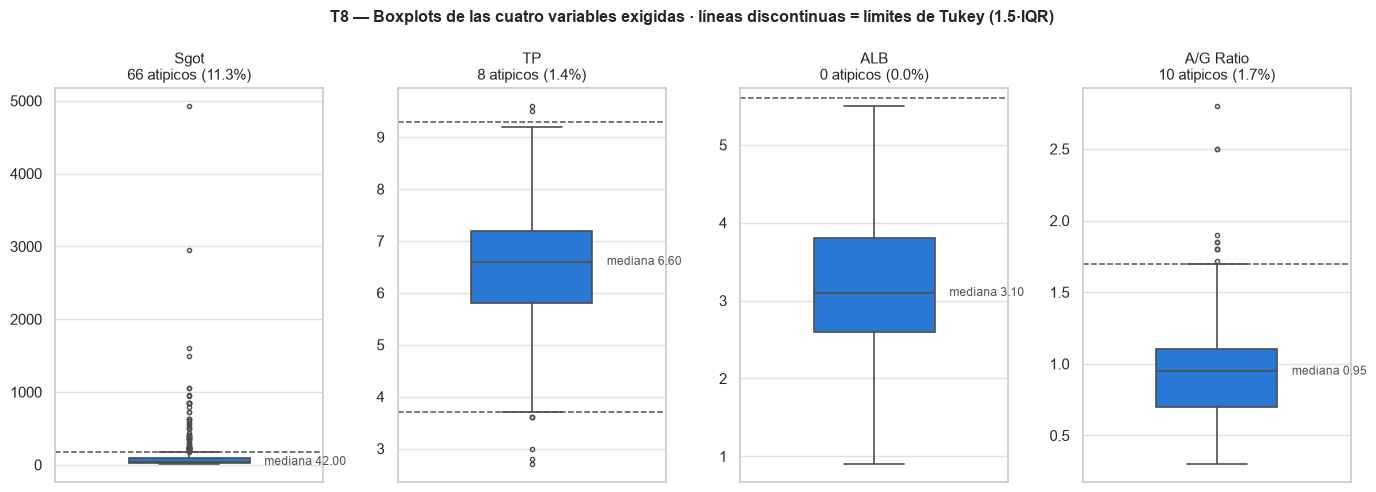

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for ax, col in zip(axes, COLS_T8):
    sns.boxplot(y=df_imputado[col], ax=ax, color="#2a78d6", width=0.45,
                fliersize=3, linewidth=1.2, saturation=1)
    lo, hi = limites_tukey(df_imputado[col])
    n_out = int(((df_imputado[col] < lo) | (df_imputado[col] > hi)).sum())

    ax.axhline(hi, color=INK_SECONDARY, linestyle="--", linewidth=1.1)
    if lo > df_imputado[col].min():
        ax.axhline(lo, color=INK_SECONDARY, linestyle="--", linewidth=1.1)

    mediana = df_imputado[col].median()
    ax.annotate(f"mediana {mediana:.2f}", xy=(0.28, mediana), fontsize=8.5,
                color=INK_SECONDARY, va="center")
    ax.set_title(f"{col}\n{n_out} atipicos ({100*n_out/len(df_imputado):.1f}%)",
                 fontsize=10.5)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="y", color=GRID_COLOR)
    ax.grid(axis="x", visible=False)

fig.suptitle("T8 — Boxplots de las cuatro variables exigidas · líneas discontinuas = límites de Tukey (1.5·IQR)",
             fontsize=11.5, fontweight="bold")
fig.tight_layout()
save_figure(fig, "fase3_t8_boxplots.png")
plt.show()

**Interpretación — F3-R11: cuántos hay y qué patrón siguen.**

### Las cuatro variables exigidas

| Variable | Límites de Tukey | Atípicos | % | Por debajo | Por encima |
|---|---|---|---|---|---|
| **`Sgot`** | [−68.0, 180.0] | **66** | **11.3%** | 0 | **66** |
| **`TP`** | [3.70, 9.30] | **8** | 1.4% | **6** | 2 |
| **`ALB`** | [0.80, 5.60] | **0** | 0.0% | 0 | 0 |
| **`A/G Ratio`** | [0.10, 1.70] | **10** | 1.7% | 0 | **10** |

### Los patrones, uno por uno

**`Sgot` — 66 atípicos, todos por arriba.** Es el caso extremo: 1 de cada 9 pacientes queda fuera del límite, y **ninguno por debajo**. Tiene sentido clínico: `Sgot` (AST) es una enzima que se derrama a la sangre cuando la célula hepática se rompe. Un valor *bajo* simplemente significa que no hay destrucción celular — no existe un "AST peligrosamente bajo". **La cola solo puede crecer hacia arriba, y hacia arriba está la gravedad.**

**`TP` — 8 atípicos, y aquí lo interesante es la dirección.** 6 están **por debajo** y solo 2 por encima. `TP` mide la producción total de proteínas del hígado, y en este eje **bajo = malo**. Esos 6 pacientes con proteína total anormalmente baja son casos de fallo de la función sintética — daño crónico avanzado. Es el único de los cuatro donde la cola relevante apunta hacia abajo.

**`ALB` — cero atípicos.** Ningún paciente queda fuera de los límites de Tukey. No significa que todos tengan albúmina normal: significa que la distribución es **estrecha y simétrica** (asimetría −0.04), sin cola en ninguna dirección. La regla de Tukey no detecta nada porque **no hay nada que sobresalga estadísticamente** — aunque clínicamente sí hay pacientes con albúmina baja. Es un recordatorio útil: **"atípico estadístico" y "anormal clínico" no son lo mismo.**

**`A/G Ratio` — 10 atípicos, todos por arriba.** Al ser un cociente, se dispara cuando el denominador (la globulina) es pequeño. Recordar que 4 de sus valores son imputados por media, y esos 4 quedan por construcción en el centro — nunca podrían ser atípicos.

### El patrón general

**En 3 de las 4 variables todos los atípicos están en el mismo extremo.** Eso no es casualidad ni error de medición: es el reflejo directo de la fisiología. Las enzimas y los productos de desecho se acumulan cuando algo falla (cola hacia arriba); las proteínas fabricadas por el hígado caen cuando la fábrica se deteriora (cola hacia abajo).

Un método de tratamiento de outliers que asuma colas simétricas **no encaja con estos datos**.

### T8.1 — [V] Outlier estadístico vs. outlier erróneo (F3-R12)

Antes de decidir qué hacer con 66 valores atípicos, hay que responder una pregunta previa: **¿son datos raros o datos equivocados?** Son cosas distintas y llevan a acciones opuestas.

| Tipo | Definición | Acción |
|---|---|---|
| **Outlier estadístico** | Lejos del centro, pero **clínicamente posible** | **Conservar y documentar** |
| **Outlier erróneo** | **Imposible** (edad negativa, `TP` = 0, `DB` > `TB`) | Corregir o marcar, justificando |

La distinción no se puede hacer con estadística: **requiere saber qué valores son biológicamente posibles.** Por eso se comprueba contra límites duros, no contra cuartiles.

In [10]:
print("=== F3-R12: los atipicos, son imposibles o solo raros? ===\n")

# Limites biologicos DUROS (no rangos de referencia: limites de lo posible).
# Fuente y alcance de cada uno: BIOLOGICAL_LIMITS_SOURCED en src/config.py.
# Solo "Sgot" tiene fuente publicada verificable (Chang et al. 2007); las
# otras tres son una estimacion razonada por el equipo, no una cita clinica
# -- ver docs/fuentes/Consulta_5.md para el detalle de la busqueda.
for col, (lo_b, hi_b) in BIOLOGICAL_LIMITS.items():
    fuera = int(((df_imputado[col] < lo_b) | (df_imputado[col] > hi_b)).sum())
    fuente = "fuente citada" if col in BIOLOGICAL_LIMITS_SOURCED else "estimacion del equipo"
    print(f"  {col:>10}: valores fuera del rango POSIBLE [{lo_b}, {hi_b}] ({fuente}) -> {fuera}")

print("\n--- El caso mas extremo: el paciente con Sgot mas alto ---")
display(df_imputado.loc[[df_imputado['Sgot'].idxmax()]])

print("--- El otro extremo: el paciente con TP mas bajo ---")
display(df_imputado.loc[[df_imputado['TP'].idxmin()]])


=== F3-R12: los atipicos, son imposibles o solo raros? ===

          TP: valores fuera del rango POSIBLE [2.0, 12.0] (estimacion del equipo) -> 0
         ALB: valores fuera del rango POSIBLE [0.5, 6.5] (estimacion del equipo) -> 0
   A/G Ratio: valores fuera del rango POSIBLE [0.1, 5.0] (estimacion del equipo) -> 0
        Sgot: valores fuera del rango POSIBLE [1, 7446] (fuente citada) -> 0

--- El caso mas extremo: el paciente con Sgot mas alto ---


,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
135,66,Male,11.3,5.6,1110,1250,4929,7.0,2.4,0.5,1


--- El otro extremo: el paciente con TP mas bajo ---


,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
180,75,Male,2.8,1.3,250,23,29,2.7,0.9,0.5,1


**Interpretación — ninguno de los atípicos de T8 es erróneo. Todos son pacientes reales.**

### La comprobación

| Variable | Rango biológicamente posible | Fuente | Valores fuera |
|---|---|---|---|
| `TP` | 2.0 – 12.0 g/dL | Estimación del equipo (sin fuente publicada verificable) | **0** |
| `ALB` | 0.5 – 6.5 g/dL | Estimación del equipo (sin fuente publicada verificable) | **0** |
| `A/G Ratio` | 0.1 – 5.0 | Estimación del equipo (sin fuente publicada verificable) | **0** |
| `Sgot` | 1 – 7 446 U/L | Piso (1): trivial, no negativo. Techo (7 446): **Chang et al. (2007)** | **0** |

> ⚠️ **Transparencia sobre las fuentes (añadido tras auditoría externa, 2026-08-15).** Una auditoría metodológica señaló que estos cuatro límites no tenían fuente citada, incumpliendo el protocolo de fundamentación clínica del proyecto (`AGENTS.md`). Se investigó: para `Sgot` existe literatura verificable — Chang et al. (2007), *Study on Analytical and Clinically Reportable Ranges*, Korean J Clin Lab Sci 39(1):31-36 — que mide con instrumentos reales hasta qué valor un ensayo de AST mantiene linealidad (rango clínicamente reportable 24–7 446 U/L). Se adopta su **techo** (7 446 U/L), más estricto que el 20 000 sin fuente usado antes; el máximo observado en el ILPD (`Sgot` = 4 929) sigue quedando por debajo, así que la conclusión no cambia, pero ahora está mejor fundamentada. El **piso** de `Sgot` se mantiene en 1 (trivial: "no puede ser negativo ni cero", sin necesidad de cita); el piso de 24 de ese mismo estudio **no** es un piso biológico, es el mínimo verificado por *esa prueba de calibración de instrumento* -- usarlo habría marcado como "erróneos" a 124 pacientes del ILPD con AST bajo pero perfectamente sano (`Sgot` mínimo observado = 10).
>
> Para `TP`, `ALB` y `A/G Ratio` **no se encontró una fuente publicada que se pudiera verificar con confianza** (búsqueda documentada en `docs/fuentes/Consulta_5.md`). En vez de dejarlos sin marcar como si fueran citas, se declaran explícitamente como lo que son: un criterio razonado por el equipo (basado en los extremos fisiológicos conocidos de cada variable), no una afirmación clínica con respaldo bibliográfico. Esto no invalida la comprobación — solo le pone la etiqueta de confianza correcta a cada número.

**Cero valores imposibles.** Los 66 atípicos de `Sgot`, los 8 de `TP` y los 10 de `A/G Ratio` son todos **outliers estadísticos**: raros, pero perfectamente posibles.

### Los dos casos extremos, leídos como pacientes

**El `Sgot` más alto (fila 135):** hombre de 66 años, `TB` = 11.3, `DB` = 5.6, `Alkphos` = 1110, `Sgpt` = 1250, `Sgot` = 4929, `ALB` = 2.4, diagnosticado.

Míralo eje por eje: bilirrubina **9 veces** el techo normal (ictericia franca), transaminasas en **miles** (destrucción celular masiva), fosfatasa alcalina en 1110 (obstrucción biliar), albúmina en 2.4 (la fábrica fallando). **Los tres ejes hepáticos alterados a la vez y de forma coherente entre sí.** No es un error de tecleo: es un paciente en fallo hepático agudo grave.

**El `TP` más bajo (fila 180):** hombre de 75 años, `TP` = 2.7, `ALB` = 0.9, `TB` = 2.8, diagnosticado.

Proteína total de 2.7 con albúmina de 0.9 — la fábrica de proteínas prácticamente parada. Otra vez coherente: no es un valor suelto y raro, es un cuadro completo de fallo sintético avanzado.

### Por qué esto decide el tratamiento

**Si los atípicos fueran errores, eliminarlos limpiaría el dataset. Como son pacientes reales y graves, eliminarlos borraría exactamente los casos que más importa detectar.**

Un modelo de cribado entrenado sin ellos aprendería a reconocer enfermedad leve y moderada, y fallaría en los casos severos — subiendo la tasa de falsos negativos justo donde el coste clínico es máximo.

**Decisión: se conservan los 583 pacientes, sin eliminar ningún valor atípico.** Lo único que se marcó como faltante en toda la fase fueron las 3 filas con `DB > TB`, que sí eran **imposibles** — la única categoría que justifica intervenir.


### T8.2 — [V] El umbral único no trata igual a todos (F3-R15 + Loop C)

Los límites de Tukey de arriba se calcularon sobre **las 583 personas juntas**. Pero este proyecto ya documentó dos veces que la población **no es homogénea**:

- **Por sexo** (ADR 0004): los rangos de referencia de varias variables difieren entre hombres y mujeres.
- **Por edad** (Loop C, CLSI C28-A3 / CALIPER): `Alkphos` es fuertemente dependiente de la edad, y los estándares de laboratorio exigen **particionar antes** de detectar atípicos, no después.

La pregunta es: **¿cuántos atípicos se detectarían si cada subgrupo se comparase consigo mismo, en vez de contra el conjunto?**

> Esto **se suma** al conteo global obligatorio, nunca lo sustituye (§0.4 del PRD).

In [11]:
print("=== F3-R15: atipicos por SEXO, umbral global vs. umbral propio ===\n")
filas = []
for col in COLS_T8:
    lo_g, hi_g = limites_tukey(df_imputado[col])
    for sexo in ("Female", "Male"):
        sub = df_imputado[df_imputado["Gender"] == sexo]
        n_global = int(((sub[col] < lo_g) | (sub[col] > hi_g)).sum())
        lo_s, hi_s = limites_tukey(sub[col])
        n_propio = int(((sub[col] < lo_s) | (sub[col] > hi_s)).sum())
        filas.append({"variable": col, "sexo": sexo, "n": len(sub),
                      "umbral_global": n_global, "pct_global": round(100*n_global/len(sub), 1),
                      "umbral_propio": n_propio, "pct_propio": round(100*n_propio/len(sub), 1),
                      "diferencia_pp": round(100*(n_propio-n_global)/len(sub), 1)})
por_sexo = pd.DataFrame(filas).set_index(["variable", "sexo"])
display(por_sexo)

print("\n=== Loop C: atipicos por EDAD, umbral global vs. umbral propio ===\n")
df_imputado["banda_edad"] = df_imputado["Age"].apply(age_band_label)
filas = []
for col in ["Alkphos"] + COLS_T8:
    lo_g, hi_g = limites_tukey(df_imputado[col])
    for banda in [f"{lo}-{hi}" for lo, hi in AGE_BANDS]:
        sub = df_imputado[df_imputado["banda_edad"] == banda]
        n_global = int(((sub[col] < lo_g) | (sub[col] > hi_g)).sum())
        lo_b, hi_b = limites_tukey(sub[col])
        n_propio = int(((sub[col] < lo_b) | (sub[col] > hi_b)).sum())
        filas.append({"variable": col, "banda": banda, "n": len(sub),
                      "umbral_global": n_global, "pct_global": round(100*n_global/len(sub), 1),
                      "umbral_propio": n_propio, "pct_propio": round(100*n_propio/len(sub), 1)})
por_edad = pd.DataFrame(filas).set_index(["variable", "banda"])
display(por_edad)

=== F3-R15: atipicos por SEXO, umbral global vs. umbral propio ===



n  umbral_global  pct_global  umbral_propio  pct_propio  \
variable  sexo                                                                
Sgot      Female  142             10         7.0             15        10.6   
          Male    441             56        12.7             50        11.3   
TP        Female  142              1         0.7              0         0.0   
          Male    441              7         1.6              7         1.6   
ALB       Female  142              0         0.0              1         0.7   
          Male    441              0         0.0              3         0.7   
A/G Ratio Female  142              3         2.1              7         4.9   
          Male    441              7         1.6              7         1.6   

                  diferencia_pp  
variable  sexo                   
Sgot      Female            3.5  
          Male             -1.4  
TP        Female           -0.7  
          Male              0.0  
ALB       Female            0.7  
          Male              0.7  
A/G Ratio Female            2.8  
          Male              0.0


=== Loop C: atipicos por EDAD, umbral global vs. umbral propio ===



n  umbral_global  pct_global  umbral_propio  pct_propio
variable  banda                                                            
Alkphos   0-17     25              4        16.0              2         8.0
          18-39   200             17         8.5             19         9.5
          40-59   225             27        12.0             28        12.4
          60-120  133             21        15.8             15        11.3
Sgot      0-17     25              2         8.0              3        12.0
          18-39   200             24        12.0             23        11.5
          40-59   225             25        11.1             28        12.4
          60-120  133             15        11.3             21        15.8
TP        0-17     25              0         0.0              3        12.0
          18-39   200              4         2.0              1         0.5
          40-59   225              1         0.4              1         0.4
          60-120  133              3         2.3              2         1.5
ALB       0-17     25              0         0.0              4        16.0
          18-39   200              0         0.0              1         0.5
          40-59   225              0         0.0              1         0.4
          60-120  133              0         0.0              0         0.0
A/G Ratio 0-17     25              0         0.0              2         8.0
          18-39   200              5         2.5              5         2.5
          40-59   225              2         0.9             10         4.4
          60-120  133              3         2.3              3         2.3

**Interpretación — el umbral único subdetecta en mujeres y sobredetecta en niños.**

### Por sexo (F3-R15)

| Variable | Sexo | n | Umbral global | Umbral propio | Diferencia |
|---|---|---|---|---|---|
| **`Sgot`** | **Female** | 142 | 10 (**7.0%**) | 15 (**10.6%**) | **+3.6 pp** |
| **`Sgot`** | Male | 441 | 56 (12.7%) | 50 (11.3%) | −1.4 pp |
| `TP` | Female | 142 | 1 (0.7%) | 0 (0.0%) | −0.7 pp |
| `TP` | Male | 441 | 7 (1.6%) | 7 (1.6%) | 0.0 pp |
| `ALB` | Female | 142 | 0 (0.0%) | 1 (0.7%) | +0.7 pp |
| `ALB` | Male | 441 | 0 (0.0%) | 3 (0.7%) | +0.7 pp |
| **`A/G Ratio`** | **Female** | 142 | 3 (**2.1%**) | 7 (**4.9%**) | **+2.8 pp** |
| `A/G Ratio` | Male | 441 | 7 (1.6%) | 7 (1.6%) | 0.0 pp |

**El patrón es consistente y va en una dirección.** En `Sgot` y `A/G Ratio` —las dos variables donde el efecto es visible— el umbral global **detecta menos atípicos en mujeres** de los que detectaría su propio grupo: 7.0% frente a 10.6%, y 2.1% frente a 4.9%.

La causa es la misma que ya vimos en Loop C con los umbrales de ALT: **los hombres son el 75.6% de la muestra**, así que los cuartiles globales están calibrados esencialmente con ellos. Una mujer con un valor elevado *para una mujer* puede quedar dentro de un límite fijado por la distribución masculina.

**Es exactamente el mismo mecanismo de sub-detección**, ahora en el tratamiento de outliers en vez de en el umbral diagnóstico. Refuerza la hipótesis registrada en Loop A.

### Por edad (Loop C)

| Variable | Banda | n | Umbral global | Umbral propio |
|---|---|---|---|---|
| **`Alkphos`** | **0-17** | 25 | 4 (**16.0%**) | 2 (**8.0%**) |
| `Alkphos` | 18-39 | 200 | 17 (8.5%) | 19 (9.5%) |
| `Alkphos` | 40-59 | 225 | 27 (12.0%) | 28 (12.4%) |
| `Alkphos` | 60-120 | 133 | 21 (15.8%) | 15 (11.3%) |
| **`ALB`** | **0-17** | 25 | 0 (0.0%) | **4 (16.0%)** |
| **`TP`** | **0-17** | 25 | 0 (0.0%) | **3 (12.0%)** |

**Se confirma la predicción de Loop C**: en `Alkphos`, el umbral global marca al **16.0%** de los menores como atípicos, y su propio umbral solo al **8.0%** — la mitad. Son niños con fosfatasa alcalina alta por **crecimiento óseo**, no por daño hepático, y el umbral adulto los penaliza.

**Y aparece el efecto inverso, que no habíamos anticipado:** en `ALB` y `TP` el umbral global marca **cero** menores, mientras que dentro de su propia banda saldrían 4 y 3. Es decir, el umbral único **no solo sobredetecta donde los niños tienen valores fisiológicamente altos — también subdetecta donde su distribución es más estrecha que la adulta.**

El error no tiene una sola dirección: **el umbral único simplemente no describe a ningún subgrupo en particular.**

### Qué se hace con esto

Nada, en esta fase. El conteo que responde a la rúbrica es el **global**, y así queda reportado. Esta estratificación es evidencia adicional de que **la decisión de tratar outliers no es neutra respecto a sexo y edad**, y se traspasa a la Fase 5 (auditoría de *fairness*) como material concreto.

### T8.3 — [V] Alternativa a eliminar: transformación logarítmica (F3-R14)

Si los valores atípicos son pacientes reales que no se pueden eliminar, pero su cola larga distorsiona escalados y distancias, queda una tercera vía: **`np.log1p`**, que comprime la cola derecha **sin borrar información ni alterar el orden entre pacientes**.

`log1p(x) = log(1 + x)` — la variante que tolera ceros.

In [12]:
print("=== F3-R14: efecto de log1p sobre asimetria y conteo de atipicos ===\n")
filas = []
for col in SKEWED_COLS + ["A/G Ratio"]:
    original = df_imputado[col]
    transformada = np.log1p(original)
    lo_o, hi_o = limites_tukey(original)
    lo_t, hi_t = limites_tukey(transformada)
    n_o = int(((original < lo_o) | (original > hi_o)).sum())
    n_t = int(((transformada < lo_t) | (transformada > hi_t)).sum())
    filas.append({"variable": col,
                  "skew_original": round(original.skew(), 2),
                  "skew_log1p": round(transformada.skew(), 2),
                  "atipicos_original": n_o,
                  "atipicos_log1p": n_t,
                  "reduccion_%": round(100 * (n_o - n_t) / n_o, 1) if n_o else np.nan})
display(pd.DataFrame(filas).set_index("variable"))

=== F3-R14: efecto de log1p sobre asimetria y conteo de atipicos ===



,skew_original,skew_log1p,atipicos_original,atipicos_log1p,reduccion_%
variable,,,,,
TB,4.89,1.72,84,51,39.3
DB,3.27,1.71,81,49,39.5
Alkphos,3.77,1.33,69,38,44.9
Sgpt,6.55,1.47,73,28,61.6
Sgot,10.55,1.23,66,22,66.7
A/G Ratio,1.00,0.23,10,4,60.0


**Interpretación — el logaritmo reduce la asimetría drásticamente, y con ella el conteo de atípicos.**

| Variable | *Skew* original | *Skew* con `log1p` | Atípicos antes | Después | Reducción |
|---|---|---|---|---|---|
| `Sgot` | **10.55** | **1.23** | 66 | **22** | **66.7%** |
| `Sgpt` | 6.55 | 1.47 | 73 | **28** | **61.6%** |
| `TB` | 4.89 | 1.72 | 84 | **51** | 39.3% |
| `Alkphos` | 3.77 | 1.33 | 69 | **38** | 44.9% |
| `DB` | 3.27 | 1.71 | 81 | **49** | 39.5% |
| `A/G Ratio` | 1.00 | 0.23 | 10 | **4** | 60.0% |

`Sgot` pasa de asimetría **10.55 a 1.23** — de una cola extrema a algo casi manejable — y sus atípicos caen de 66 a 22.

### ⚠️ Lo que esto NO significa

**No significa que "sobren" 44 atípicos de `Sgot`.** Los pacientes son los mismos; lo único que cambió es la **escala en la que se los mide**. La regla de Tukey no detecta enfermedad: detecta *distancia respecto de los cuartiles*, y esa distancia depende de la escala elegida.

Leerlo como "el logaritmo eliminó outliers" sería el error clásico. Lo correcto es: **el logaritmo cambió la pregunta**. En escala original preguntamos "¿quién está lejos en unidades absolutas?"; en escala logarítmica, "¿quién está lejos en órdenes de magnitud?". Para biomarcadores, la segunda pregunta suele ser la más informativa — pasar de 30 a 60 U/L es un cambio más comparable a pasar de 300 a 600 que a pasar de 300 a 330.

### Recomendación

`log1p` es la alternativa preferible a eliminar valores atípicos, porque **conserva a todos los pacientes y todo el orden entre ellos**. Pero no es gratis: cambia la interpretación de la variable, y hay que declararlo.

La Fase 2c ya aportó evidencia independiente de que esta transformación **no es opcional** cuando se usan métodos basados en distancias — sin ella, el clustering aislaba pacientes individuales en vez de encontrar grupos.

---

## Guardado del dataset procesado (F3-R16)

Se guardan **tres versiones** en `data/processed/`, para que la Fase 4 pueda elegir sin volver a ejecutar este notebook:

| Archivo | Contenido |
|---|---|
| `ilpd_procesado.csv` | Imputado (media/moda), sin escalar. **El dataset de referencia.** |
| `ilpd_zscore.csv` | Con Z-Score aplicado — el escalado que este notebook concluye como preferible |
| `ilpd_log_zscore.csv` | Con `log1p` + Z-Score — la variante de valor agregado |

> `data/raw/` permanece **intacto**. Es el principio de inmutabilidad del §7.3 del PRD: todo el análisis debe poder re-ejecutarse desde cero.

In [13]:
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

salida = df_imputado.drop(columns=["banda_edad"])

versiones = {
    "ilpd_procesado.csv": salida,
    "ilpd_zscore.csv": pd.concat(
        [salida[["Gender", TARGET_COL]], X_zscore], axis=1)[salida.columns],
    "ilpd_log_zscore.csv": pd.concat(
        [salida[["Gender", TARGET_COL]], X_logz], axis=1)[salida.columns],
}

for nombre, datos in versiones.items():
    ruta = DATA_PROCESSED_DIR / nombre
    datos.to_csv(ruta, index=False)
    print(f"{nombre:>22}  {datos.shape[0]} x {datos.shape[1]}  "
          f"| nulos: {int(datos.isna().sum().sum())}")

print(f"\nGuardado en: {DATA_PROCESSED_DIR.relative_to(PROJECT_ROOT).as_posix()}/")
print(f"Dataset crudo intacto: {load_raw_data().shape} (sin modificar)")

    ilpd_procesado.csv  583 x 11  | nulos: 6
       ilpd_zscore.csv  583 x 11  | nulos: 6
   ilpd_log_zscore.csv  583 x 11  | nulos: 6

Guardado en: data/processed/
Dataset crudo intacto: (583, 11) (sin modificar)


**Nota sobre los 6 nulos en los archivos guardados.**

Las tres versiones conservan los **6 valores faltantes** de `TB` y `DB` (las 3 filas con `DB > TB`). Es deliberado, por las razones desarrolladas en T6: son valores **medidos pero imposibles**, y rellenarlos con la media destruiría el registro de que son desconocidos.

La Fase 4 tiene tres caminos abiertos: usar un modelo que tolere faltantes, imputarlos dentro del `Pipeline`, o descartar esas 3 filas (0.5% de la muestra).

---

## Notas para fases futuras (no se ejecuta nada aquí)

### Fase 4+ — Modelado (fuera del alcance de este PRD)

- ⚠️ **Fuga de datos.** El `SimpleImputer` de T6 y los escaladores de T7 se ajustaron aquí sobre el **dataset completo**, lo cual es válido porque no se entrena nada. En el pipeline de modelado deben ir **dentro de un `Pipeline` ajustado solo con el train set**.
- ⚠️ **Los 13 duplicados y el *split*.** Se conservaron (F3-R13). Al particionar train/test, las copias idénticas podrían caer en particiones distintas y **filtrar información del train al test**. La solución es agrupar por fila idéntica antes de particionar, no eliminarlas ahora.
- **Recodificar `Selector`** de {1, 2} a {1, 0} antes de entrenar.
- **Escalado recomendado:** Z-Score, o `log1p` + Z-Score si el modelo usa distancias o gradientes. Los modelos de árboles (Random Forest, Gradient Boosting) son ***scale-invariant*** y no lo necesitan.
- **Evaluar VIF** antes de descartar `Sgpt` o `Sgot` — Straw & Wu muestran que pesan distinto según el sexo.

### Fase 5 — Auditoría de *fairness* (fuera del alcance de este PRD)

- **El tratamiento de outliers no es neutro respecto al sexo.** Con umbral global, `Sgot` marca al 7.0% de las mujeres; con su propio umbral, al 10.6%. Es el mismo mecanismo de sub-detección que Loop C encontró en los umbrales de ALT, ahora en otra etapa del pipeline.
- **Ni respecto a la edad.** En `Alkphos`, el umbral global marca al 16.0% de los menores frente al 8.0% de su propio umbral; en `ALB` y `TP` el efecto se invierte. El umbral único no describe bien a ningún subgrupo.
- **Los duplicados están sobrerrepresentados en hombres** (84.6% vs 75.6%). Cualquier decisión sobre ellos afecta más a un sexo que al otro.

### Fase E — Entregables

- Los estadísticos de **T3 se reportan sobre los datos originales**, no sobre los imputados: la imputación por media reduce la varianza (−0.687% medido en `A/G Ratio`) y distorsionaría justamente lo que T3 mide.
- Limitaciones a declarar: no hay rango de referencia validado para Andhra Pradesh; `Age` tiene doble problema de calidad (*heaping* + *top-coding*); el dataset carece de variable de etiología.